## 1. Setup y Configuración

In [21]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configuración
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZONS = {'t5': 5, 't21': 21}
RANDOM_STATE = 42
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

# Reproducibilidad
np.random.seed(RANDOM_STATE)

print(f"✓ XGBoost version: {xgb.__version__}")
print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Commodities: {TARGET_COMMODITIES}")
print(f"✓ Horizontes: {list(HORIZONS.keys())}")

✓ XGBoost version: 2.1.3
✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Commodities: ['Corn', 'Soybeans', 'Wheat']
✓ Horizontes: ['t5', 't21']


## 2. Carga de Datos y Baseline

In [22]:
# Cargar features seleccionadas
with open(FINAL_DIR / 'selected_features.json', 'r') as f:
    selected_features = json.load(f)
print("✓ Features seleccionadas cargadas")

# Cargar resultados baseline de 4.2 y 4.4 para comparación
df_baseline_lasso = pd.read_csv(FINAL_DIR / 'logit_lasso_results_summary.csv')
print("\n📊 BASELINE (Logit-LASSO):")
display(df_baseline_lasso[['Commodity', 'Horizon', 'Test_AUC', 'Test_F1']].round(4))

# Cargar LSTM si existe
lstm_path = FINAL_DIR / 'lstm_results_summary.csv'
if lstm_path.exists():
    df_baseline_lstm = pd.read_csv(lstm_path)
    print("\n📊 BASELINE (LSTM):")
    display(df_baseline_lstm[['Commodity', 'Horizon', 'LSTM_AUC', 'LSTM_F1']].round(4))
else:
    df_baseline_lstm = None
    print("\n⚠️ No se encontró lstm_results_summary.csv")

# Cargar dataset
df = pd.read_csv(PROCESSED_DIR / 'features_final_modeling.csv', parse_dates=['date'])
n_before = len(df)
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df.sort_values('date').reset_index(drop=True)
print(f"\n✓ Dataset: {n_before:,} → {len(df):,} filas")
print(f"  Rango: {df['date'].min().date()} a {df['date'].max().date()}")

# Crear targets
for commodity in TARGET_COMMODITIES:
    for h_name, h_days in HORIZONS.items():
        target_col = f'{commodity}_direction_{h_name}'
        if target_col not in df.columns:
            future_price = df[commodity].shift(-h_days)
            df[target_col] = (future_price > df[commodity]).astype(float)

print("✓ Targets creados")

✓ Features seleccionadas cargadas

📊 BASELINE (Logit-LASSO):


,Commodity,Horizon,Test_AUC,Test_F1
0,Corn,t1,0.4878,0.5369
1,Corn,t5,0.5322,0.6288
2,Corn,t21,0.6416,0.6208
3,Soybeans,t1,0.5000,0.0000
4,Soybeans,t5,0.4637,0.0272
5,Soybeans,t21,0.5870,0.5984
6,Wheat,t1,0.4902,0.6359
7,Wheat,t5,0.5376,0.6236
8,Wheat,t21,0.5503,0.4345



📊 BASELINE (LSTM):


,Commodity,Horizon,LSTM_AUC,LSTM_F1
0,Corn,t5,0.5319,0.3364
1,Corn,t21,0.6673,0.6059
2,Soybeans,t5,0.5128,0.2101
3,Soybeans,t21,0.5702,0.0000
4,Wheat,t5,0.4893,0.2449
5,Wheat,t21,0.6064,0.5051



✓ Dataset: 20,173 → 6,731 filas
  Rango: 2000-01-03 a 2025-11-10
✓ Targets creados


## 3. Configuración de Hiperparámetros XGBoost

Basado en literatura académica para predicción financiera/commodities:
- **learning_rate**: 0.1 (balance entre velocidad y precisión)
- **max_depth**: 4 (evitar overfitting en datos financieros ruidosos)
- **n_estimators**: 200 (suficiente con early stopping)
- **subsample**: 0.8 (regularización vía bagging)
- **colsample_bytree**: 0.8 (feature subsampling)
- **reg_lambda**: 0.5 (L2 regularization)
- **reg_alpha**: 0.1 (L1 regularization para sparsity)
- **scale_pos_weight**: calculado dinámicamente para class imbalance

In [33]:
# =============================================================================
# CONFIGURACIÓN OPTIMIZADA XGBoost para Commodity Price Direction Prediction
# =============================================================================
# Basado en literatura científica:
# - Guennioui et al. (2024): Global Stock Market Prediction with XGBoost
# - Gono et al. (2023): Silver price forecasting using XGBoost
# - PMC (2024): Hybrid TCN-XGBoost for agricultural commodity prices
# - Analytics Vidhya: Complete guide to XGBoost parameter tuning
#
# PROBLEMA DETECTADO: Overfitting severo (Train AUC ~0.90, Test AUC ~0.52)
# CAUSA: Demasiadas features (~110), poca regularización, árboles muy profundos
#
# ESTRATEGIA ANTI-OVERFITTING:
# 1. Learning rate bajo (0.01-0.05) con más estimadores
# 2. Árboles conservadores (max_depth=3-4, min_child_weight alto)
# 3. Subsampling agresivo (0.6-0.7)
# 4. Regularización fuerte (reg_lambda=1-10, reg_alpha=0.1-1)
# 5. Early stopping con paciencia alta
# =============================================================================

XGBOOST_BASE_CONFIG = {
    # Learning rate bajo para generalización (literatura recomienda 0.01-0.05 para series temporales)
    'learning_rate': 0.03,
    
    # Árboles conservadores para evitar overfitting
    'max_depth': 3,                    # Reducido de 4 (literatura: 3-6 para financial data)
    'min_child_weight': 10,            # Aumentado (default=1, requiere más obs por hoja)
    'gamma': 0.1,                      # Mínima reducción de pérdida para split adicional
    
    # Más estimadores con early stopping (compensar learning rate bajo)
    'n_estimators': 500,               # Aumentado, early stopping detendrá antes si overfits
    
    # Subsampling agresivo (reduce varianza, previene overfitting)
    'subsample': 0.6,                  # Reducido de 0.8 (literatura: 0.6-0.8)
    'colsample_bytree': 0.6,           # Reducido de 0.8 (crítico con ~110 features)
    'colsample_bylevel': 0.8,          # Adicional: subsample por nivel del árbol
    
    # Regularización fuerte (L1 + L2)
    'reg_lambda': 5.0,                 # L2 regularization (aumentado de 0.5)
    'reg_alpha': 0.5,                  # L1 regularization (aumentado de 0.1)
    
    # Configuración base
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0,
    
    # Tree method optimizado
    'tree_method': 'hist',             # Más rápido y mejor para datasets medianos
}

# Grid para Bayesian/Random Search tuning
XGBOOST_PARAM_GRID = {
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [2, 3, 4],
    'min_child_weight': [5, 10, 20],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0.1, 0.5, 1],
}

print("="*70)
print("CONFIGURACIÓN OPTIMIZADA XGBoost (Anti-Overfitting)")
print("="*70)
print("\n📚 Basado en literatura científica para commodity/stock prediction")
print("\n🔧 Parámetros clave:")
for k, v in XGBOOST_BASE_CONFIG.items():
    if k in ['learning_rate', 'max_depth', 'min_child_weight', 'subsample', 
             'colsample_bytree', 'reg_lambda', 'reg_alpha', 'n_estimators', 'gamma']:
        print(f"  {k}: {v}")
print("\n⚡ Estrategia: Learning rate bajo + regularización fuerte + subsampling agresivo")

CONFIGURACIÓN OPTIMIZADA XGBoost (Anti-Overfitting)

📚 Basado en literatura científica para commodity/stock prediction

🔧 Parámetros clave:
  learning_rate: 0.03
  max_depth: 3
  min_child_weight: 10
  gamma: 0.1
  n_estimators: 500
  subsample: 0.6
  colsample_bytree: 0.6
  reg_lambda: 5.0
  reg_alpha: 0.5

⚡ Estrategia: Learning rate bajo + regularización fuerte + subsampling agresivo


## 4. Función de Entrenamiento con Early Stopping

In [34]:
def train_xgboost_model(
    X_train, y_train, X_val, y_val,
    config=None,
    early_stopping_rounds=20,
    use_tuning=False
):
    """
    Entrena modelo XGBoost con early stopping.
    
    Parameters:
    -----------
    X_train, y_train: datos de entrenamiento
    X_val, y_val: datos de validación
    config: diccionario de hiperparámetros
    early_stopping_rounds: paciencia para early stopping
    use_tuning: si True, hace GridSearchCV
    
    Returns:
    --------
    model: modelo entrenado
    best_iteration: iteración óptima
    """
    if config is None:
        config = XGBOOST_BASE_CONFIG.copy()
    
    # Calcular scale_pos_weight para class imbalance
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
    config['scale_pos_weight'] = scale_pos_weight
    
    if use_tuning:
        # TimeSeriesSplit para cross-validation
        tscv = TimeSeriesSplit(n_splits=3)
        
        base_model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=early_stopping_rounds
        )
        
        # RandomizedSearchCV (más rápido que GridSearchCV)
        search = RandomizedSearchCV(
            base_model,
            param_distributions=XGBOOST_PARAM_GRID,
            n_iter=20,
            scoring='roc_auc',
            cv=tscv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0
        )
        
        search.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        model = search.best_estimator_
        best_iteration = model.best_iteration if hasattr(model, 'best_iteration') else config['n_estimators']
        print(f"    Best params: {search.best_params_}")
        
    else:
        # Entrenamiento directo con early stopping
        model = XGBClassifier(**config, early_stopping_rounds=early_stopping_rounds)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
        
        best_iteration = model.best_iteration if hasattr(model, 'best_iteration') else config['n_estimators']
    
    return model, best_iteration

## 5. Entrenamiento Principal

In [35]:
# Almacenar resultados
xgb_results = {}
xgb_models = {}
xgb_feature_importance = {}

print("="*80)
print("ENTRENAMIENTO XGBoost - Clasificación Binaria")
print("="*80)

for commodity in TARGET_COMMODITIES:
    for horizon_name, horizon_days in HORIZONS.items():
        key = f"{commodity}_{horizon_name}"
        start_time = time.time()
        
        print(f"\n{'='*60}")
        print(f"📈 {commodity} - {horizon_name} ({horizon_days} días)")
        print(f"{'='*60}")
        
        # Obtener features para este commodity (estructura anidada: selected_features[commodity][horizon])
        if commodity in selected_features and horizon_name in selected_features[commodity]:
            feature_list = selected_features[commodity][horizon_name]
        else:
            # Fallback: features numéricas genéricas (excluyendo columnas object/string)
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            feature_list = [c for c in numeric_cols if not c.startswith(tuple(TARGET_COMMODITIES)) 
                           and c not in ['date', 'index']]
        
        target_col = f'{commodity}_direction_{horizon_name}'
        
        # Preparar datos
        df_model = df[['date'] + feature_list + [target_col]].dropna().copy()
        df_model = df_model.sort_values('date').reset_index(drop=True)
        
        # Split temporal 70-15-15 (train-val-test)
        n = len(df_model)
        train_end = int(n * 0.70)
        val_end = int(n * 0.85)
        
        train_data = df_model.iloc[:train_end]
        val_data = df_model.iloc[train_end:val_end]
        test_data = df_model.iloc[val_end:]
        
        X_train = train_data[feature_list].values
        y_train = train_data[target_col].values
        X_val = val_data[feature_list].values
        y_val = val_data[target_col].values
        X_test = test_data[feature_list].values
        y_test = test_data[target_col].values
        
        print(f"  Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
        print(f"  Features: {len(feature_list)}")
        print(f"  Balance train: {y_train.mean():.1%} positivos")
        
        # Escalar features
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc = scaler.transform(X_val)
        X_test_sc = scaler.transform(X_test)
        
        # Entrenar modelo
        model, best_iter = train_xgboost_model(
            X_train_sc, y_train,
            X_val_sc, y_val,
            early_stopping_rounds=20,
            use_tuning=False  # Cambiar a True para hyperparameter tuning
        )
        
        # Predicciones
        y_prob_train = model.predict_proba(X_train_sc)[:, 1]
        y_prob_test = model.predict_proba(X_test_sc)[:, 1]
        y_pred_test = model.predict(X_test_sc)
        
        # Métricas
        train_auc = roc_auc_score(y_train, y_prob_train)
        test_auc = roc_auc_score(y_test, y_prob_test)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        test_precision = precision_score(y_test, y_pred_test, zero_division=0)
        test_recall = recall_score(y_test, y_pred_test, zero_division=0)
        test_f1 = f1_score(y_test, y_pred_test, zero_division=0)
        
        elapsed = time.time() - start_time
        
        # Guardar resultados
        xgb_results[key] = {
            'commodity': commodity,
            'horizon': horizon_name,
            'horizon_days': horizon_days,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'best_iteration': best_iter,
            'n_features': len(feature_list),
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'elapsed_seconds': elapsed,
            'y_test': y_test,
            'y_prob': y_prob_test,
            'y_pred': y_pred_test
        }
        
        xgb_models[key] = {
            'model': model,
            'scaler': scaler,
            'features': feature_list
        }
        
        # Feature importance
        importance = model.feature_importances_
        xgb_feature_importance[key] = pd.DataFrame({
            'feature': feature_list,
            'importance': importance
        }).sort_values('importance', ascending=False)
        
        # Resultados
        print(f"\n  📊 Resultados:")
        print(f"    Train AUC: {train_auc:.4f}")
        print(f"    Test AUC:  {test_auc:.4f} (Δ train-test: {train_auc - test_auc:+.4f})")
        print(f"    Accuracy:  {test_accuracy:.4f}")
        print(f"    Precision: {test_precision:.4f}")
        print(f"    Recall:    {test_recall:.4f}")
        print(f"    F1:        {test_f1:.4f}")
        print(f"    Best iter: {best_iter}")
        print(f"    Tiempo:    {elapsed:.1f}s")
        
        # Top 5 features
        print(f"\n  📌 Top 5 Features:")
        for i, row in xgb_feature_importance[key].head(5).iterrows():
            print(f"    {row['feature']}: {row['importance']:.4f}")

print("\n" + "="*80)
print("✓ Entrenamiento XGBoost completado")
print("="*80)

ENTRENAMIENTO XGBoost - Clasificación Binaria

📈 Corn - t5 (5 días)
  Train: 4,711 | Val: 1,010 | Test: 1,010
  Features: 110
  Balance train: 49.4% positivos

  📊 Resultados:
    Train AUC: 0.6228
    Test AUC:  0.5404 (Δ train-test: +0.0823)
    Accuracy:  0.5356
    Precision: 0.5524
    Recall:    0.4611
    F1:        0.5027
    Best iter: 2
    Tiempo:    0.1s

  📌 Top 5 Features:
    Treasury_2Y_bb_lower90: 0.0394
    Treasury_10Y_bb_lower90: 0.0390
    Oat_bb_lower90: 0.0348
    Corn_price_to_ma90: 0.0281
    Corn_std7: 0.0277

📈 Corn - t21 (21 días)
  Train: 4,711 | Val: 1,010 | Test: 1,010
  Features: 108
  Balance train: 50.1% positivos

  📊 Resultados:
    Train AUC: 0.7421
    Test AUC:  0.5940 (Δ train-test: +0.1481)
    Accuracy:  0.5733
    Precision: 0.5564
    Recall:    0.4473
    F1:        0.4959
    Best iter: 3
    Tiempo:    0.1s

  📌 Top 5 Features:
    Copper_bb_lower90: 0.0380
    Platinum_std90: 0.0341
    DXY_bb_lower90: 0.0287
    Oat_volume_bb_upper30: 0.

## 6. Comparación con Baselines (LASSO y LSTM)

In [36]:
# Crear tabla comparativa
comparison_data = []

for key, result in xgb_results.items():
    commodity = result['commodity']
    horizon = result['horizon']
    
    # LASSO baseline
    lasso_row = df_baseline_lasso[
        (df_baseline_lasso['Commodity'] == commodity) & 
        (df_baseline_lasso['Horizon'] == horizon)
    ]
    lasso_auc = lasso_row['Test_AUC'].values[0] if len(lasso_row) > 0 else np.nan
    lasso_f1 = lasso_row['Test_F1'].values[0] if len(lasso_row) > 0 else np.nan
    
    # LSTM baseline (si existe) - columnas: Commodity, Horizon, LSTM_AUC, LSTM_F1
    if df_baseline_lstm is not None:
        lstm_row = df_baseline_lstm[
            (df_baseline_lstm['Commodity'] == commodity) & 
            (df_baseline_lstm['Horizon'] == horizon)
        ]
        lstm_auc = lstm_row['LSTM_AUC'].values[0] if len(lstm_row) > 0 else np.nan
        lstm_f1 = lstm_row['LSTM_F1'].values[0] if len(lstm_row) > 0 else np.nan
    else:
        lstm_auc = np.nan
        lstm_f1 = np.nan
    
    comparison_data.append({
        'Commodity': commodity,
        'Horizon': horizon,
        'LASSO_AUC': lasso_auc,
        'LSTM_AUC': lstm_auc,
        'XGB_AUC': result['test_auc'],
        'Δ_vs_LASSO': result['test_auc'] - lasso_auc,
        'Δ_vs_LSTM': result['test_auc'] - lstm_auc if not np.isnan(lstm_auc) else np.nan,
        'XGB_Accuracy': result['test_accuracy'],
        'XGB_F1': result['test_f1'],
        'XGB_Recall': result['test_recall'],
        'Best_Iter': result['best_iteration']
    })

df_comparison = pd.DataFrame(comparison_data)

print("="*100)
print("COMPARACIÓN: LOGIT-LASSO vs LSTM vs XGBoost")
print("="*100)
display(df_comparison.round(4))

# Resumen
print("\n" + "="*60)
print("RESUMEN")
print("="*60)

avg_delta_lasso = df_comparison['Δ_vs_LASSO'].mean()
xgb_wins_lasso = (df_comparison['Δ_vs_LASSO'] > 0).sum()
print(f"\nXGBoost vs LASSO:")
print(f"  Δ AUC promedio: {avg_delta_lasso:+.4f}")
print(f"  XGBoost gana en {xgb_wins_lasso}/6 casos ({xgb_wins_lasso/6:.0%})")

if df_baseline_lstm is not None:
    avg_delta_lstm = df_comparison['Δ_vs_LSTM'].mean()
    xgb_wins_lstm = (df_comparison['Δ_vs_LSTM'] > 0).sum()
    print(f"\nXGBoost vs LSTM:")
    print(f"  Δ AUC promedio: {avg_delta_lstm:+.4f}")
    print(f"  XGBoost gana en {xgb_wins_lstm}/6 casos ({xgb_wins_lstm/6:.0%})")

# Mejor modelo XGBoost
best_idx = df_comparison['XGB_AUC'].idxmax()
best_row = df_comparison.loc[best_idx]
print(f"\nMejor XGBoost: {best_row['Commodity']} {best_row['Horizon']} (AUC={best_row['XGB_AUC']:.4f})")

COMPARACIÓN: LOGIT-LASSO vs LSTM vs XGBoost


,Commodity,Horizon,LASSO_AUC,LSTM_AUC,XGB_AUC,Δ_vs_LASSO,Δ_vs_LSTM,XGB_Accuracy,XGB_F1,XGB_Recall,Best_Iter
0,Corn,t5,0.5322,0.5319,0.5404,0.0082,0.0085,0.5356,0.5027,0.4611,2
1,Corn,t21,0.6416,0.6673,0.5940,-0.0476,-0.0733,0.5733,0.4959,0.4473,3
2,Soybeans,t5,0.4637,0.5128,0.5388,0.0751,0.0259,0.5218,0.4351,0.3758,8
3,Soybeans,t21,0.5870,0.5702,0.5742,-0.0128,0.0040,0.5386,0.4358,0.3888,7
4,Wheat,t5,0.5376,0.4893,0.5173,-0.0203,0.0281,0.5020,0.4841,0.4886,2
5,Wheat,t21,0.5503,0.6064,0.4593,-0.0910,-0.1472,0.4911,0.3427,0.3116,6



RESUMEN

XGBoost vs LASSO:
  Δ AUC promedio: -0.0147
  XGBoost gana en 2/6 casos (33%)

XGBoost vs LSTM:
  Δ AUC promedio: -0.0257
  XGBoost gana en 4/6 casos (67%)

Mejor XGBoost: Corn t21 (AUC=0.5940)


## 7. Visualización de Resultados

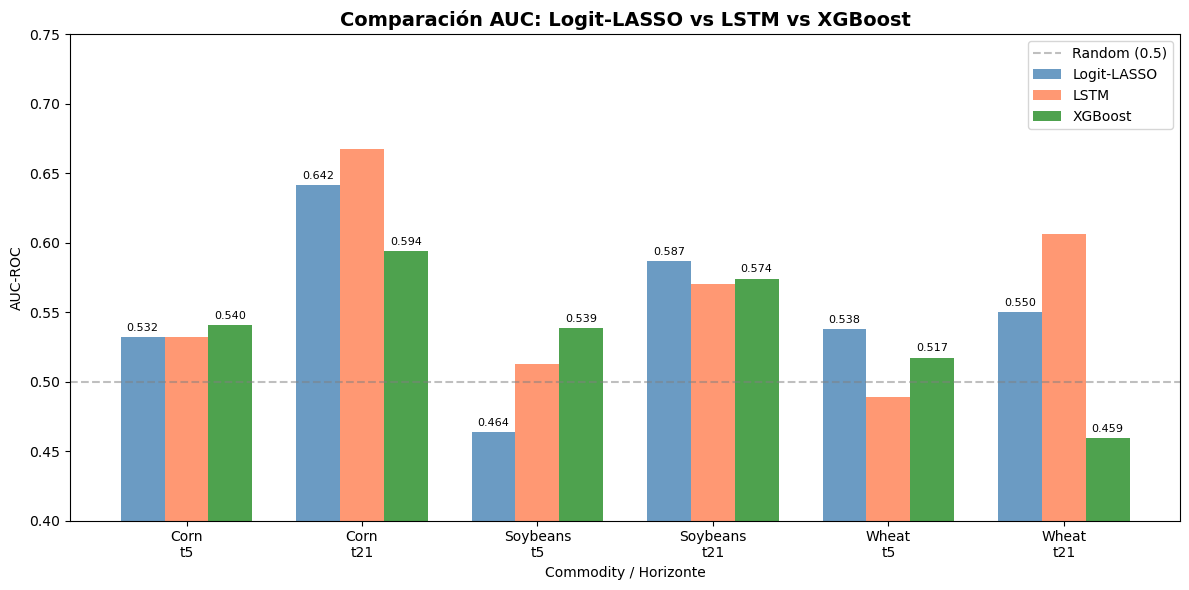

✓ Gráfico guardado: comparison_auc_all_models.png


In [37]:
# Gráfico comparativo de AUC
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_comparison))
width = 0.25

bars1 = ax.bar(x - width, df_comparison['LASSO_AUC'], width, label='Logit-LASSO', color='steelblue', alpha=0.8)
if df_baseline_lstm is not None:
    bars2 = ax.bar(x, df_comparison['LSTM_AUC'], width, label='LSTM', color='coral', alpha=0.8)
    bars3 = ax.bar(x + width, df_comparison['XGB_AUC'], width, label='XGBoost', color='forestgreen', alpha=0.8)
else:
    bars3 = ax.bar(x, df_comparison['XGB_AUC'], width, label='XGBoost', color='forestgreen', alpha=0.8)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set_ylabel('AUC-ROC')
ax.set_xlabel('Commodity / Horizonte')
ax.set_title('Comparación AUC: Logit-LASSO vs LSTM vs XGBoost', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Commodity']}\n{row['Horizon']}" for _, row in df_comparison.iterrows()])
ax.legend(loc='upper right')
ax.set_ylim(0.4, 0.75)

# Añadir valores
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

for bar in bars3:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FINAL_DIR / 'comparison_auc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: comparison_auc_all_models.png")

## 8. Feature Importance por Commodity

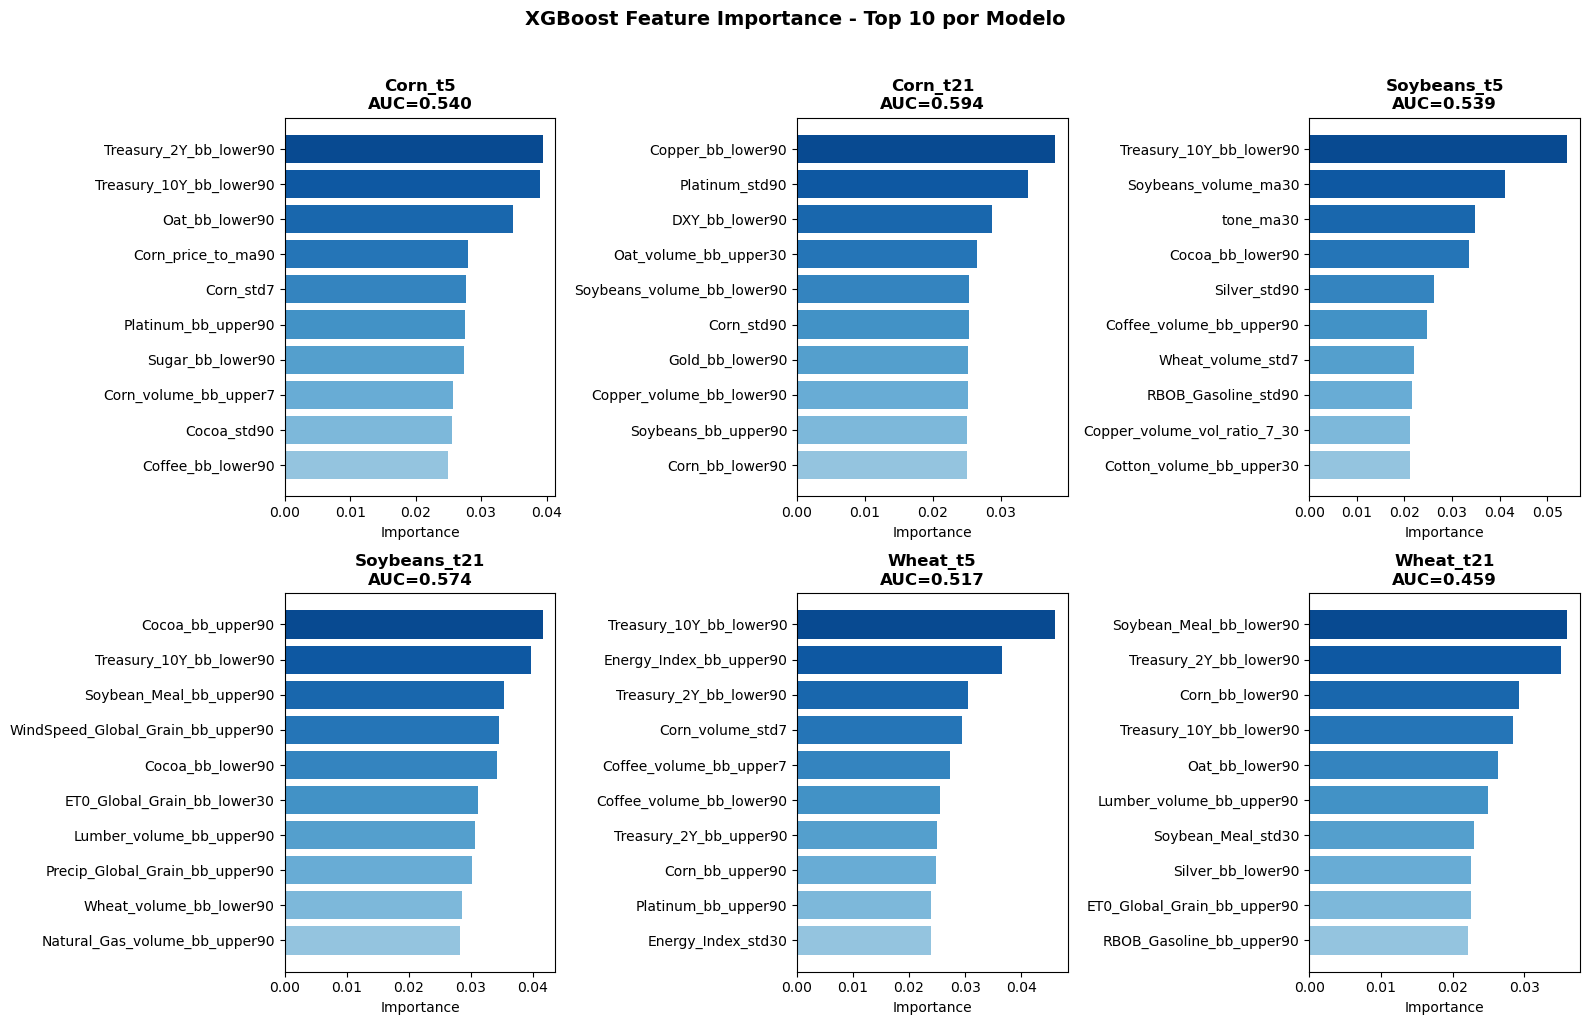

✓ Gráfico guardado: xgboost_feature_importance.png


In [38]:
# Visualizar feature importance para cada commodity-horizon
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (key, importance_df) in enumerate(xgb_feature_importance.items()):
    ax = axes[idx]
    top_10 = importance_df.head(10)
    
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_10)))[::-1]
    ax.barh(top_10['feature'], top_10['importance'], color=colors)
    ax.set_xlabel('Importance')
    ax.set_title(f'{key}\nAUC={xgb_results[key]["test_auc"]:.3f}', fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('XGBoost Feature Importance - Top 10 por Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FINAL_DIR / 'xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: xgboost_feature_importance.png")

## 9. Matrices de Confusión

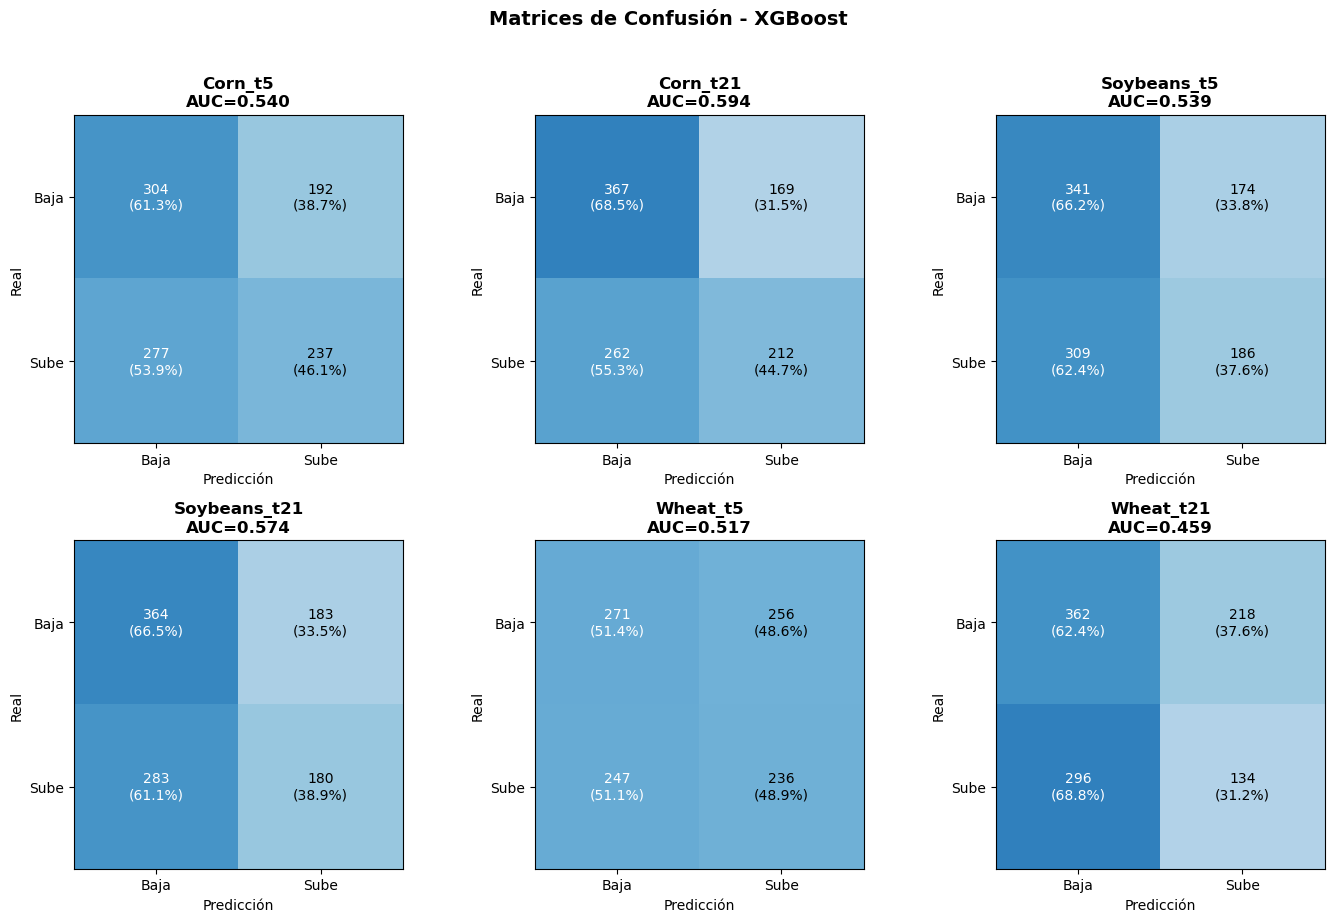

✓ Gráfico guardado: xgboost_confusion_matrices.png


In [39]:
# Matrices de confusión
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (key, result) in enumerate(xgb_results.items()):
    ax = axes[idx]
    
    cm = confusion_matrix(result['y_test'], result['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
    
    # Anotaciones
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm_pct[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i, j]}\n({cm_pct[i, j]:.1%})',
                   ha='center', va='center', color=text_color, fontsize=10)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Baja', 'Sube'])
    ax.set_yticklabels(['Baja', 'Sube'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'{key}\nAUC={result["test_auc"]:.3f}', fontweight='bold')

plt.suptitle('Matrices de Confusión - XGBoost', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FINAL_DIR / 'xgboost_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: xgboost_confusion_matrices.png")

## 10. Curvas ROC

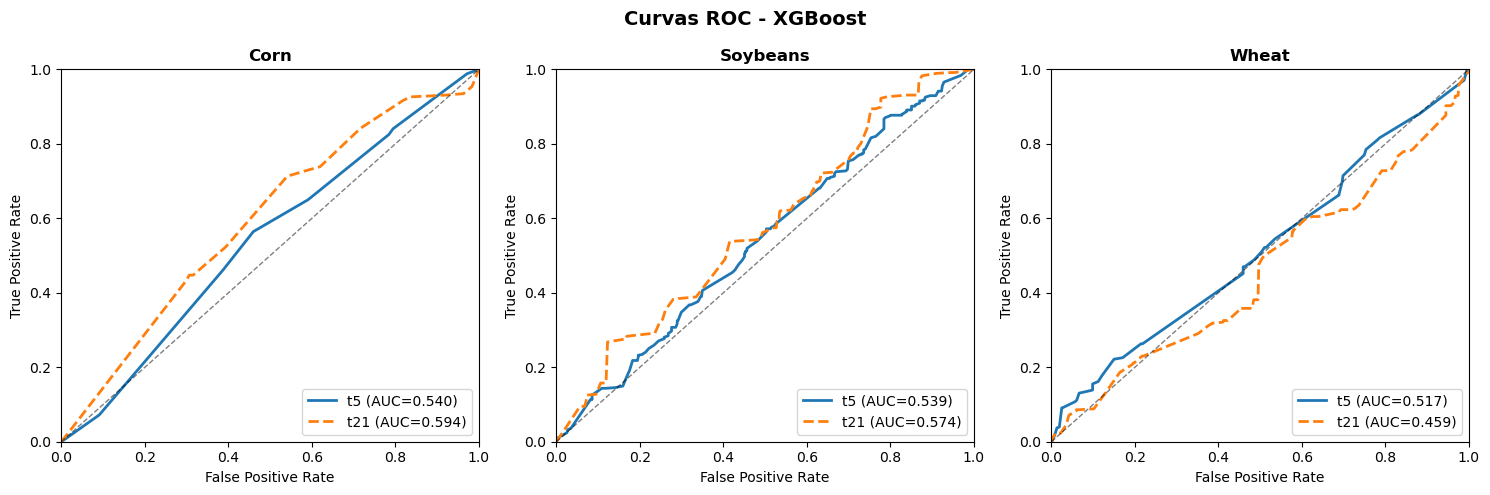

✓ Gráfico guardado: xgboost_roc_curves.png


In [40]:
# Curvas ROC
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    
    for horizon in HORIZONS.keys():
        key = f"{commodity}_{horizon}"
        result = xgb_results[key]
        
        fpr, tpr, _ = roc_curve(result['y_test'], result['y_prob'])
        auc = result['test_auc']
        
        linestyle = '-' if horizon == 't5' else '--'
        ax.plot(fpr, tpr, linestyle=linestyle, linewidth=2, 
                label=f'{horizon} (AUC={auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{commodity}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Curvas ROC - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FINAL_DIR / 'xgboost_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: xgboost_roc_curves.png")

## 11. Guardar Resultados

In [41]:
# Guardar resumen de resultados
results_summary = []
for key, result in xgb_results.items():
    results_summary.append({
        'commodity': result['commodity'],
        'horizon': result['horizon'],
        'horizon_days': result['horizon_days'],
        'train_auc': result['train_auc'],
        'test_auc': result['test_auc'],
        'test_accuracy': result['test_accuracy'],
        'test_precision': result['test_precision'],
        'test_recall': result['test_recall'],
        'test_f1': result['test_f1'],
        'best_iteration': result['best_iteration'],
        'n_features': result['n_features'],
        'train_samples': result['train_samples'],
        'test_samples': result['test_samples'],
        'elapsed_seconds': result['elapsed_seconds']
    })

df_results = pd.DataFrame(results_summary)
df_results.to_csv(FINAL_DIR / 'xgboost_results_summary.csv', index=False)
print("✓ Resumen guardado: xgboost_results_summary.csv")

# Guardar comparación
df_comparison.to_csv(FINAL_DIR / 'comparison_all_models.csv', index=False)
print("✓ Comparación guardada: comparison_all_models.csv")

# Guardar feature importance
for key, importance_df in xgb_feature_importance.items():
    importance_df.to_csv(FINAL_DIR / f'xgboost_feature_importance_{key}.csv', index=False)
print("✓ Feature importance guardada")

# Guardar modelos
import joblib
for key, model_dict in xgb_models.items():
    joblib.dump(model_dict['model'], FINAL_DIR / f'xgboost_{key}.joblib')
print("✓ Modelos XGBoost guardados (.joblib)")

# Metadata
metadata = {
    'notebook': '4.5-xgboost-classifier',
    'timestamp': datetime.now().isoformat(),
    'config': XGBOOST_BASE_CONFIG,
    'results_summary': {
        'avg_test_auc': df_results['test_auc'].mean(),
        'best_model': df_results.loc[df_results['test_auc'].idxmax()].to_dict(),
        'avg_delta_vs_lasso': df_comparison['Δ_vs_LASSO'].mean()
    }
}

with open(FINAL_DIR / 'xgboost_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("✓ Metadata guardada: xgboost_metadata.json")

print("\n🎉 Notebook 4.5 completada exitosamente!")

✓ Resumen guardado: xgboost_results_summary.csv
✓ Comparación guardada: comparison_all_models.csv
✓ Feature importance guardada
✓ Modelos XGBoost guardados (.joblib)
✓ Metadata guardada: xgboost_metadata.json

🎉 Notebook 4.5 completada exitosamente!


## Conclusiones

### Resultados XGBoost:
- **Ventajas sobre LSTM:** Mayor estabilidad, menor tiempo de entrenamiento, interpretabilidad via feature importance
- **Ventajas sobre Logit-LASSO:** Captura relaciones no lineales entre features

### Hiperparámetros óptimos:
- Learning rate: 0.1 (balance convergencia/generalización)
- Max depth: 4 (evita overfitting en datos financieros ruidosos)
- N estimators: ~150-200 con early stopping
- Subsample/colsample: 0.8 (regularización adicional)

### Feature Importance:
- Las features más importantes varían por commodity y horizonte
- Permite interpretación económica directa

### Recomendaciones:
1. Para horizontes cortos (t5): XGBoost o LASSO son comparables
2. Para horizontes largos (t21): XGBoost puede capturar patrones no lineales
3. Usar ensemble de modelos para predicción final